# HOUSE PRICE PREDICTION - LINEAR REGRESSION MODEL

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

print("Loaded Required Libraries")

Loaded Required Libraries


In [4]:
df=pd.read_csv("house_price_dataset.csv")
df

,Square_Footage,Bedrooms,Bathrooms,House_Price
0,1460,3,4,268191
1,4372,1,1,533161
2,3692,6,3,580697
3,1066,3,2,169891
4,4044,2,1,524419
...,...,...,...,...
995,640,5,1,165090
996,2681,1,3,391776
997,2222,4,3,354739
998,941,3,4,213406


In [5]:
# Features (Independent Variables)
X = df[['Square_Footage', 'Bedrooms', 'Bathrooms']]
X

,Square_Footage,Bedrooms,Bathrooms
0,1460,3,4
1,4372,1,1
2,3692,6,3
3,1066,3,2
4,4044,2,1
...,...,...,...
995,640,5,1
996,2681,1,3
997,2222,4,3
998,941,3,4


In [7]:
# Target (Dependent Variable)
y = df['House_Price']
y

0      268191
1      533161
2      580697
3      169891
4      524419
        ...  
995    165090
996    391776
997    354739
998    213406
999    617280
Name: House_Price, Length: 1000, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Square_Footage  1000 non-null   int64
 1   Bedrooms        1000 non-null   int64
 2   Bathrooms       1000 non-null   int64
 3   House_Price     1000 non-null   int64
dtypes: int64(4)
memory usage: 31.4 KB


In [11]:
df.describe()

,Square_Footage,Bedrooms,Bathrooms,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,2854.807000,3.458000,2.521000,418616.467000
std,1221.734084,1.704447,1.136156,151050.508415
min,603.000000,1.000000,1.000000,97321.000000
25%,1816.250000,2.000000,2.000000,291502.000000
50%,2871.500000,3.000000,2.000000,423826.000000
75%,3881.500000,5.000000,4.000000,540149.250000
max,4989.000000,6.000000,4.000000,737320.000000


In [15]:
# Check for Null values

null_values = df.isnull().sum()
print("\nTotal Null Values:", df.isnull().sum().sum())


Total Null Values: 0


In [16]:
# Check for duplicate values
duplicate_values = df.duplicated().sum()
print("Total Duplicate Rows:", duplicate_values)

Total Duplicate Rows: 0


In [19]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [23]:
# Train Linear Regression Model
model=LinearRegression()
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
model.fit(X_train,y_train)
print("\nModel Training Completed!")


Model Training Completed!


In [39]:
# Make Prediction
y_pred = model.predict(X_test)

print(y_pred[:10])

[280188.54473959 183017.2469887  445799.10742835 245559.04198102
 418023.86330035 464871.10444817 516317.77019741 521004.40328678
 338184.52468087 290235.39726608]


In [40]:
# Evaluate Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


In [41]:
print("\nModel Evaluation")
print("------------------------")
print(f"Mean Absolute Error  : {mae:.2f}")
print(f"Mean Squared Error   : {mse:.2f}")
print(f"Root Mean Squared Error : {rmse:.2f}")
print(f"R2 Score             : {r2:.4f}")



Model Evaluation
------------------------
Mean Absolute Error  : 15159.21
Mean Squared Error   : 297829395.15
Root Mean Squared Error : 17257.73
R2 Score             : 0.9875


In [42]:
# Predict New House Price
new_house = [[2500, 4, 3]]

predicted_price = model.predict(new_house)
print(f"Predicted House Price: ${predicted_price[0]:,.2f}")

Predicted House Price: $388,716.90


C:\anaconda\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


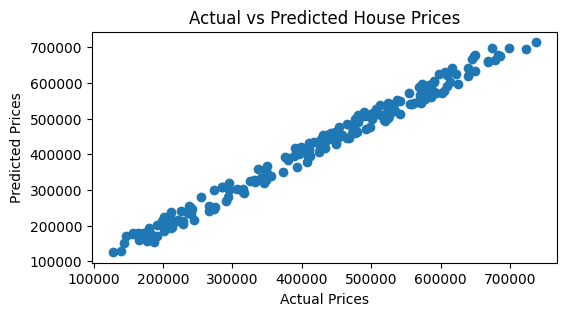

In [43]:
# Visualization
plt.figure(figsize=(6,3))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()